In [2]:
import pypsa
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import xarray as xr

In [3]:
n_base = pypsa.Network('base_s_1__none_2035_lt.nc')
n_stoch = pypsa.Network('stochastic_network.nc')

INFO:pypsa.io:Imported network base_s_1__none_2035_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores
INFO:pypsa.io:Imported network stochastic_network.nc has buses, generators, links, loads, stores


In [4]:
from typing import Dict, Any

# CO2 price path by year (€/tCO2)
co2_prices = {
    "2020": 28,
    "2025": 70,
    "2030": 130,
    "2035": 190,
    "2040": 210,
    "2045": 530,
}

# Direct specific emissions per carrier (tCO2 per MWh in the same basis as marginal_cost)
specific_emissions = {
    "oil" : 0.2571,
    "oil primary" : 0.2571,
    "gas" : 0.198,  # OCGT
    "gas primary" : 0.198,  # OCGT
    "coal" : 0.3361,
    "lignite" : 0.4069,
    "solid biomass": 0.3667
}

# Add carbon costs to generator marginal costs according to the chosen CO2 price
def add_carbon_price(n, co2_price, specific_emissions):
        
    for carrier in specific_emissions.keys():
        n.generators.loc[n.generators.carrier == carrier, "marginal_cost"] += (
            co2_price * specific_emissions[carrier]
        )

# Configure short-term operation with hydrogen stores and initial energy levels
def build_st_network(n, e_initial_h2 = 1e6):

    # Select all hydrogen-related stores (case-insensitive match on "H2")
    stores = n.stores[n.stores.carrier.str.contains("H2", case=False, na=False)].index

    # Set store marginal costs to the mean H2 bus price and disable cyclic state of charge
    for i in stores:
        n.stores.loc[i, 'marginal_cost'] = n_base.buses_t.marginal_price['DE0 0 H2'].mean()
        n.stores.loc[i, 'e_cyclic'] = False

    # Initialize hydrogen energy content for each vintage-specific store
    n.stores.loc['DE0 0 H2 Store-2035', 'e_initial'] = e_initial_h2
    n.stores.loc['DE0 0 H2 Store-2030', 'e_initial'] = 0
    n.stores.loc['DE0 0 H2 Store-2020', 'e_initial'] = 0

    # Fix capacities and create the dispatch optimization model
    n.optimize.fix_optimal_capacities()
    n.optimize.create_model()

    return n

In [5]:
# set the marginal price from the stochastic network as marginal cost of the new network (negative because minimization/maximization)

def myopic_battery(n, n_stoch):
    stores = n.stores[n.stores.carrier.str.contains("battery", case=False, na=False)].index

    for store in stores:
        n.stores_t.marginal_cost[store] = -n_stoch.buses_t.marginal_price['DE0 0 battery']


## Heuristic vs. Classic Optimization

### Classic Optimization

In [6]:
# optimize with perfect foresight and without the heuristic
n_perfect_foresight = n_base.copy()

add_carbon_price(n_perfect_foresight, co2_prices["2035"], specific_emissions)

n_perfect_foresight.optimize.fix_optimal_capacities()
n_perfect_foresight.optimize.create_model()

n_perfect_foresight.optimize.solve_model(
    solver_name = 'gurobi'
)

{'DE', 'EU'}
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2637156


INFO:gurobipy:Set parameter LicenseID to value 2637156


...

Solved in 96602 iterations and 23.39 seconds (12.62 work units)


INFO:gurobipy:Solved in 96602 iterations and 23.39 seconds (12.62 work units)


Optimal objective  9.762864002e+10


INFO:gurobipy:Optimal objective  9.762864002e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 732907 primals, 1509641 duals
Objective: 9.76e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

### Heuristic Optimization

In [7]:
# optimize with perfect foresight and with the heuristic

n_heuristic = n_base.copy()

add_carbon_price(n_heuristic, co2_prices["2035"], specific_emissions)
myopic_battery(n_heuristic, n_stoch)
n_heuristic.optimize.fix_optimal_capacities()
n_heuristic.optimize.create_model()

n_heuristic.optimize.solve_model(
    solver_name = 'gurobi'
)

{'DE', 'EU'}
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2637156


INFO:gurobipy:Set parameter LicenseID to value 2637156


...

Solved in 100584 iterations and 27.50 seconds (12.14 work units)


INFO:gurobipy:Solved in 100584 iterations and 27.50 seconds (12.14 work units)


Optimal objective  9.635972188e+10


INFO:gurobipy:Optimal objective  9.635972188e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 732907 primals, 1509641 duals
Objective: 9.64e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

### Electricity Price Comparison

In [8]:
lmps = pd.DataFrame()


lmps = pd.concat([lmps, n_perfect_foresight.buses_t.marginal_price['DE0 0'].rename('N PF')], axis=1)
lmps = pd.concat([lmps, n_heuristic.buses_t.marginal_price['DE0 0'].rename('N Heuristic')], axis=1)


lmps.describe()

,N PF,N Heuristic
count,2920.000000,2920.000000
mean,93.514014,94.684818
std,75.641523,77.723164
min,0.035117,0.029340
25%,34.840541,10.542688
50%,87.085005,88.547090
75%,125.479381,133.649092
max,285.472705,330.246035


### Electricity Price Comparison Plot

Text(0, 0.5, '€ / MWh')

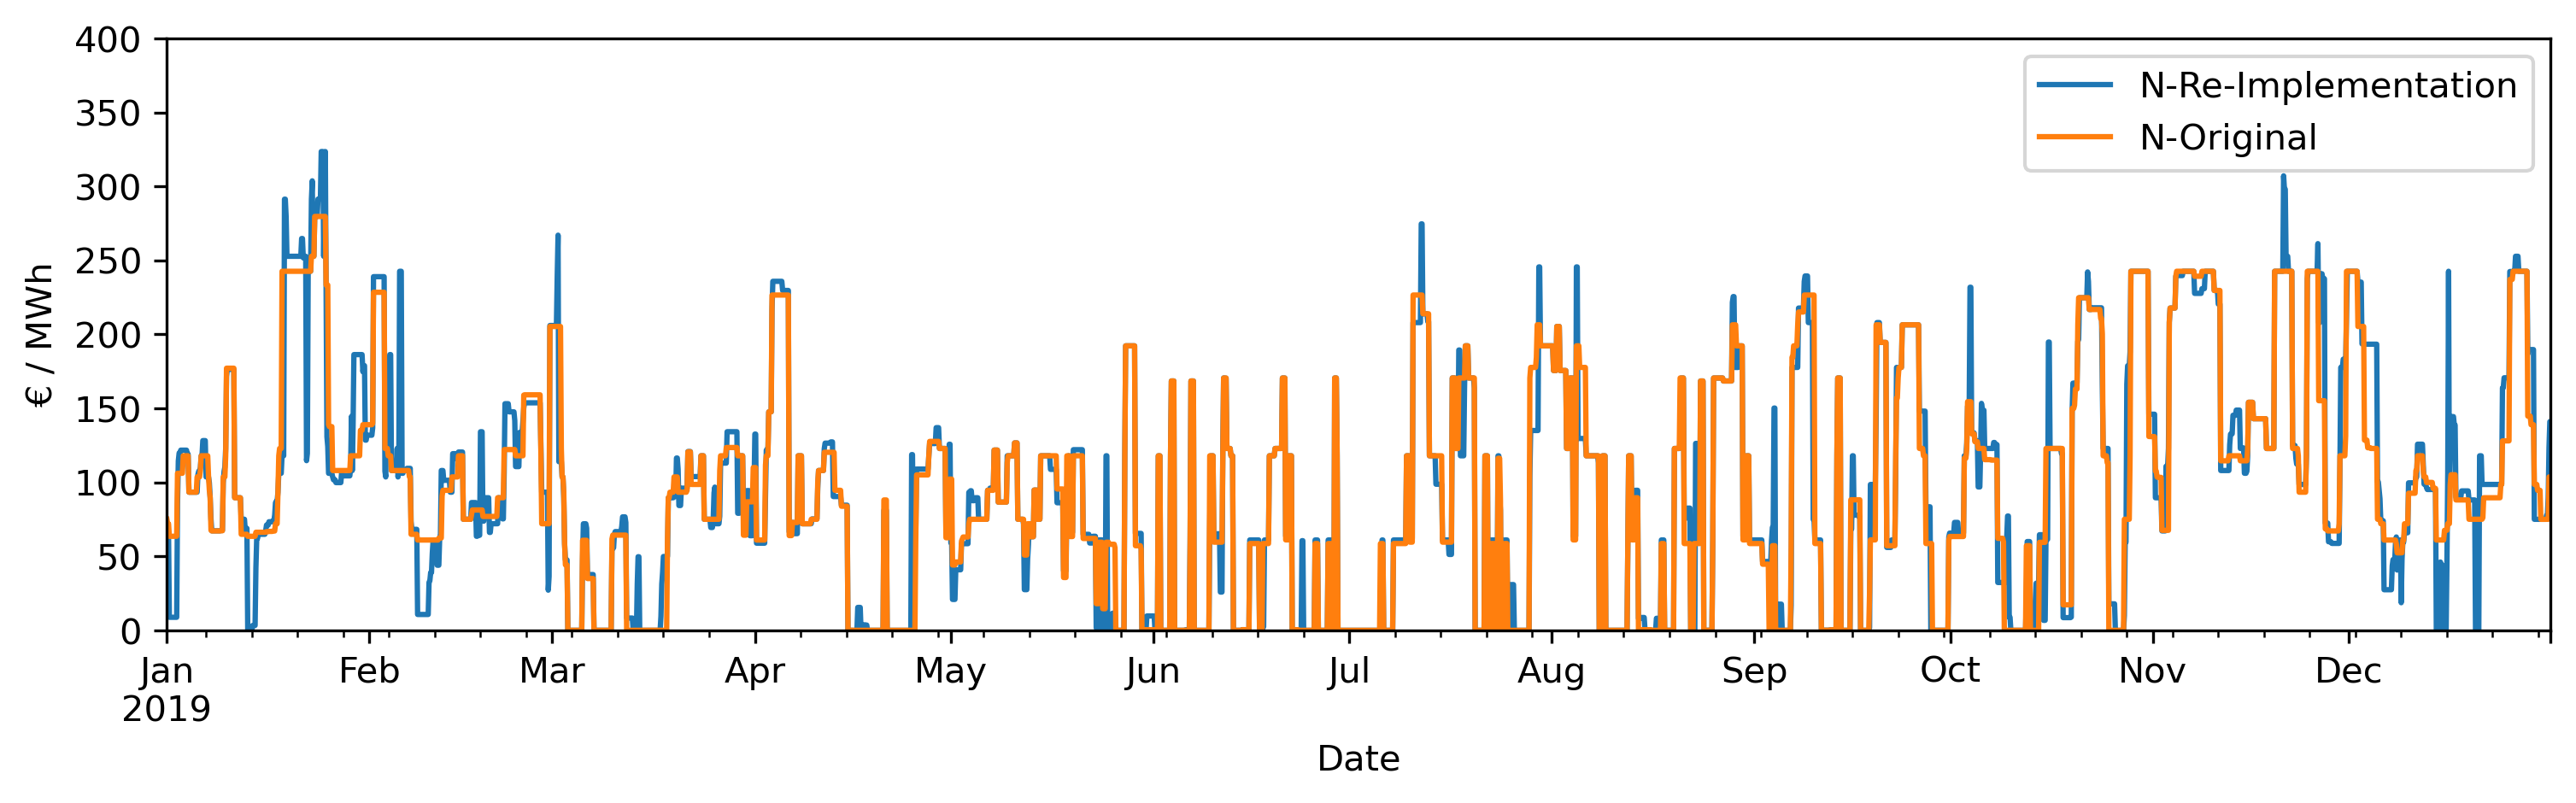

In [9]:
fig, ax = plt.subplots(figsize=(12,3), dpi=300)

n_heuristic.buses_t.marginal_price['DE0 0 battery'].plot(
    label='N-Re-Implementation',
    ylim=(0,400)
)
n_perfect_foresight.buses_t.marginal_price['DE0 0 battery'].plot(
    label='N-Original'
)

#plt.title('Comparison of the Electricity Price between N-Heuristic and N-Original ')
plt.legend()

plt.xlabel('Date')
plt.ylabel('€ / MWh')

### Generation

In [10]:
gen = pd.DataFrame()

gen = pd.concat([gen, 
                 round(n_heuristic.statistics.supply(bus_carrier="AC") / 1e6, 1)]
                 ,axis=1)
gen = pd.concat([gen, 
                 round(n_perfect_foresight.statistics.supply(bus_carrier="AC") / 1e6, 1)]
                 ,axis=1)

gen = gen.drop([('Link', 'H2 Fuel Cell'),
                ('Link', 'solid biomass'),
                ('Link', 'oil'),
                ('Link', 'Open-Cycle Gas'),
                ('Link', 'urban central lignite CHP'),
                ('Link', 'urban central oil CHP'),

])
gen.columns = ['N-PF', 'N-Heuristic']
gen = gen.fillna(0.0)
gen

N-PF  N-Heuristic
Link        CCGT                              27.5         25.2
            H2 OCGT                            6.1          6.5
            H2 retrofit OCGT                   1.3          0.4
            battery discharger                53.8         54.8
            coal                               2.5          2.5
            lignite                            3.9          2.1
            urban central coal CHP             4.1          4.0
            urban central gas CHP             47.7         46.3
            urban central solid biomass CHP    0.4          0.3
StorageUnit Pumped Hydro Storage               4.9          3.9
            Reservoir & Dam                    1.7          1.7
Generator   Offshore Wind (AC)                30.5         30.5
            Offshore Wind (DC)               199.3        199.9
            Onshore Wind                     278.0        278.6
            Run of River                      15.3         15.3
            Solar                            157.2        156.9
            solar-hsat                       165.7        166.0

### Price Duration Curve

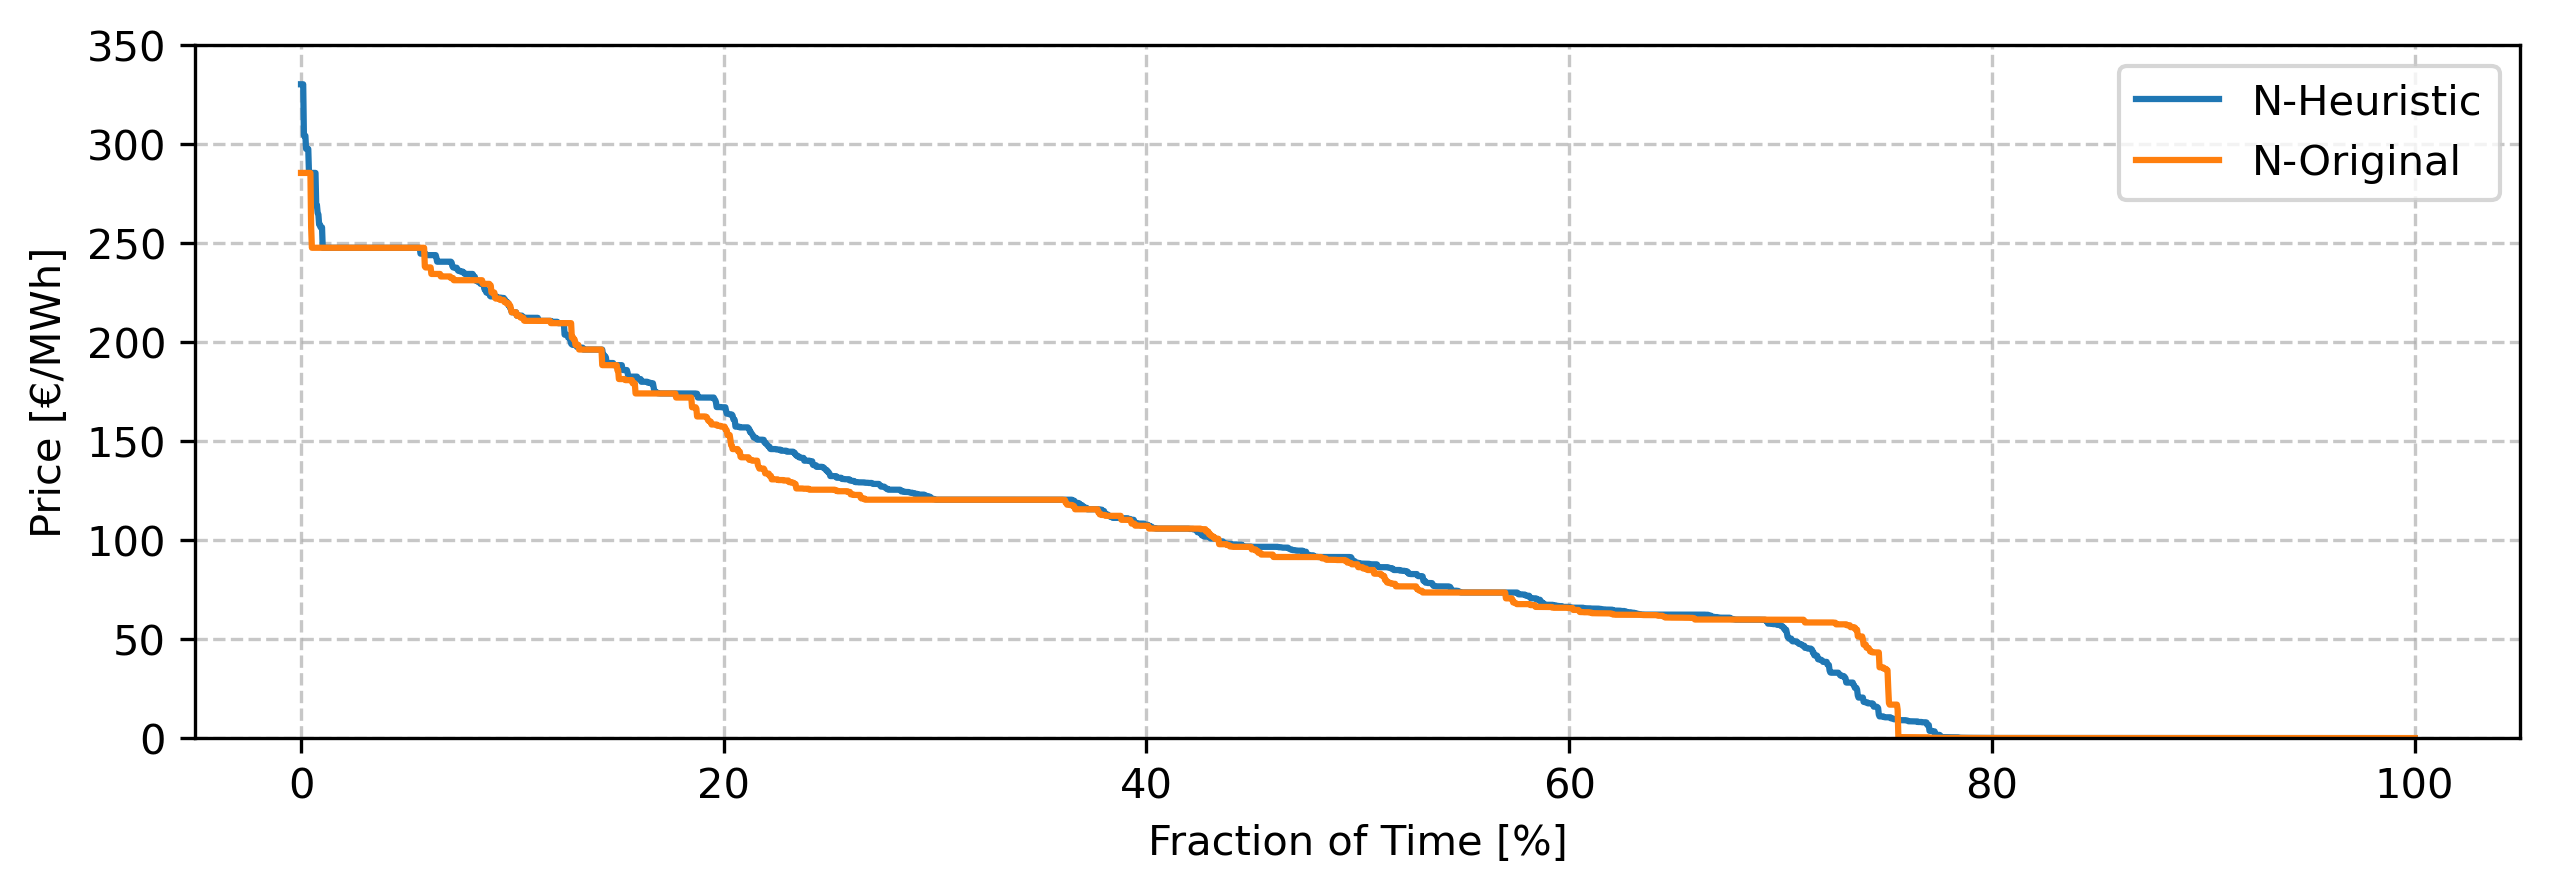

In [11]:
# Beispiel: falls dein DataFrame df eine Spalte 'Preis' hat
preise = pd.DataFrame()
preise = pd.concat([preise, n_heuristic.buses_t.marginal_price['DE0 0'].sort_values(ascending=False).reset_index(drop=True).rename('N-H')], axis=1)
preise = pd.concat([preise, n_perfect_foresight.buses_t.marginal_price['DE0 0'].sort_values(ascending=False).reset_index(drop=True).rename('n_PF')], axis=1)



# Dauerachse in Prozent (0–100)
dauer = np.linspace(0, 100, len(preise))

# Plot
plt.figure(figsize=(10,3), dpi=300)
plt.plot(dauer, preise, label=['N-Heuristic', 'N-Original'])
plt.xlabel("Fraction of Time [%]")
plt.ylabel("Price [€/MWh]")  # Einheit anpassen
#plt.title("Residual Price Curve")
plt.grid(True, linestyle="--", alpha=0.7)
plt.ylim(0,350)
plt.legend()

plt.show()